In [163]:
import torch
import numpy as np
torch.__version__

'2.11.0'

In [164]:
from sklearn import datasets
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [165]:
iris['data'].shape, iris['data'].dtype

((150, 4), dtype('float64'))

In [166]:
iris['data'][:15]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2]])

In [167]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [168]:
np.unique(iris['target'])

array([0, 1, 2])

In [169]:
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

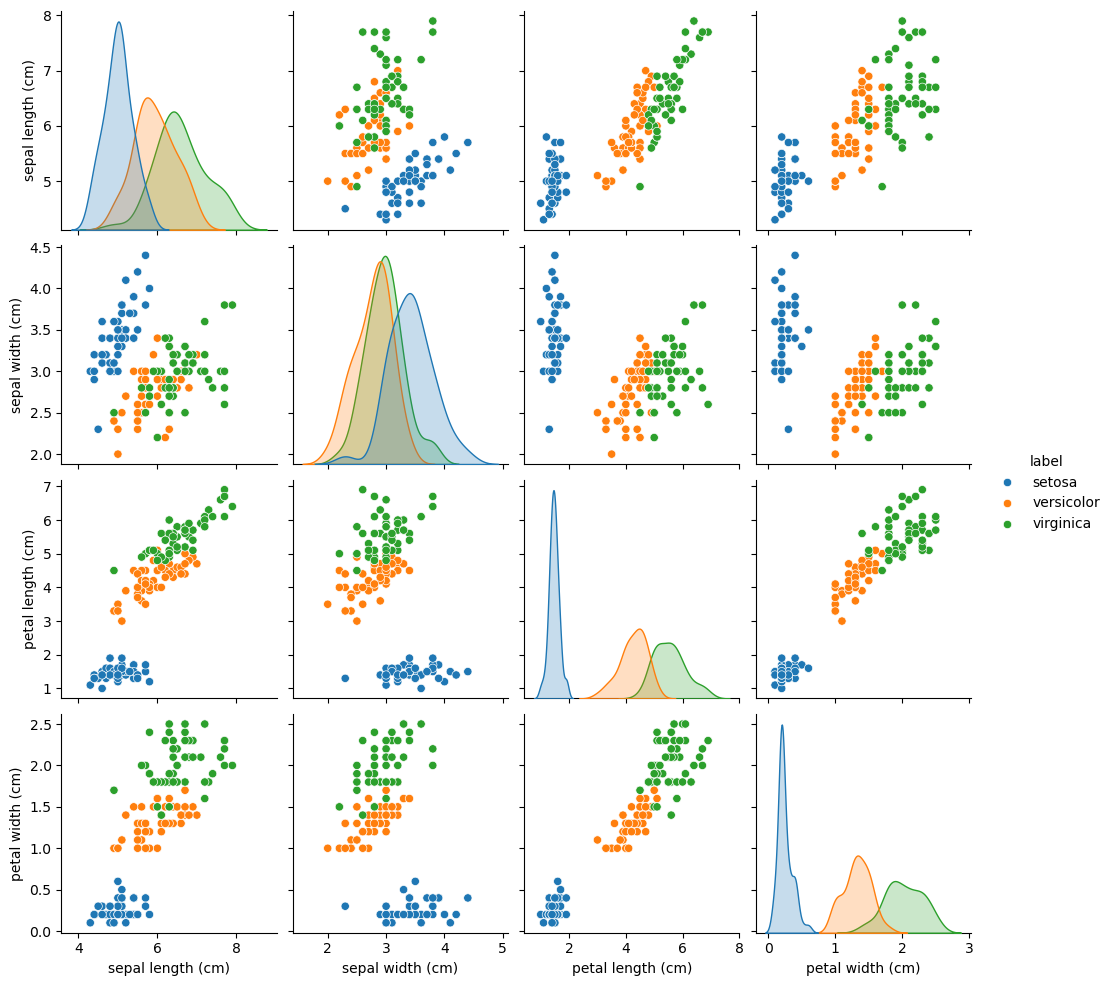

In [170]:
%matplotlib inline
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

features_df = pd.DataFrame(
    iris['data'],
    columns=iris['feature_names']
)
features_df['label'] = iris['target_names'][iris['target']]
sns.pairplot(features_df, hue='label')
plt.show()

In [171]:
preprocessed_features = (iris['data'] - iris['data'].mean(axis=0)) / iris['data'].std(axis=0)

iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

**Assessed Question: Why do we want to do this?**

To prevent overfitting. We need new data to test on to ensure it's trained on the flowers in general rather than just the data in this set.

**Assessed Question: Why do we need to shuffle before splitting it? Hint: take a look at the entire dataset array.**

Because the data is ordered so the training set would be completely unrealted to the testing set.

In [172]:
from sklearn.model_selection import train_test_split

labels = iris['target']
train_features, test_features, train_labels, test_labels = train_test_split(preprocessed_features, labels, test_size=1/3)

In [173]:
features = {
    'train': torch.tensor(train_features, dtype=torch.float32),
    'test': torch.tensor(test_features, dtype=torch.float32),
}
labels = {
    'train': torch.tensor(train_labels, dtype=torch.long),
    'test': torch.tensor(test_labels, dtype=torch.long),}

In [174]:
from torch import nn
from torch.nn import functional as F
from typing import Callable

class MLP(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_layer_size: int,
                 output_size: int,
                 activation_fn: Callable[[torch.Tensor], torch.Tensor] = F.relu):
        super().__init__()
        self.l1 = nn.Linear(input_size, hidden_layer_size)
        self.l2 = nn.Linear(hidden_layer_size, output_size)
        self.activation_fn = activation_fn

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        x = self.l1(inputs)
        x = self.activation_fn(x)
        x = self.l2(x)
        return x

In [175]:
feature_count = 4
hidden_layer_size = 100
class_count = 3
model = MLP(feature_count, hidden_layer_size, class_count)

In [176]:
logits = model.forward(features['train'])
logits.shape

torch.Size([100, 3])

In [177]:
loss_function = nn.CrossEntropyLoss()

loss = loss_function(logits, labels['train'])
loss.backward()

In [199]:
def accuracy(probs: torch.FloatTensor, targets: torch.LongTensor) -> float:
    maximums = torch.argmax(probs, dim=1)
    compare = torch.eq(maximums, targets)
    sum = torch.sum(compare)
    return sum.item()/len(compare)

In [200]:
def check_accuracy(probs: torch.FloatTensor,
                   labels: torch.LongTensor,
                   expected_accuracy: float):
    actual_accuracy = float(accuracy(probs, labels))
    assert actual_accuracy == expected_accuracy, f"Expected accuracy to be {expected_accuracy} but was {actual_accuracy}"

check_accuracy(torch.tensor([[0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               1.0)
check_accuracy(torch.tensor([[1, 0],
                             [0, 1],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               0.8)
check_accuracy(torch.tensor([[1, 0],
                             [1, 0],
                             [0, 1],
                             [0, 1],
                             [0, 1]]),
               torch.ones(5, dtype=torch.long),
               0.6)
check_accuracy(torch.tensor([[1, 0],
                             [1, 0],
                             [1, 0],
                             [1, 0],
                             [1, 0]]),
               torch.ones(5, dtype=torch.long),
               0.0)
print("All test cases passed")

All test cases passed


epoch: 0 train accuracy: 34.00, loss: 1.07187
epoch: 1 train accuracy: 64.00, loss: 0.95465
epoch: 2 train accuracy: 65.00, loss: 0.78490
epoch: 3 train accuracy: 70.00, loss: 0.63001
epoch: 4 train accuracy: 74.00, loss: 0.51640
epoch: 5 train accuracy: 80.00, loss: 0.43597
epoch: 6 train accuracy: 84.00, loss: 0.37538
epoch: 7 train accuracy: 87.00, loss: 0.32784
epoch: 8 train accuracy: 90.00, loss: 0.29130
epoch: 9 train accuracy: 90.00, loss: 0.26487
epoch: 10 train accuracy: 91.00, loss: 0.24718
epoch: 11 train accuracy: 92.00, loss: 0.23615
epoch: 12 train accuracy: 89.00, loss: 0.22944
epoch: 13 train accuracy: 90.00, loss: 0.22481
epoch: 14 train accuracy: 91.00, loss: 0.22057
epoch: 15 train accuracy: 92.00, loss: 0.21575
epoch: 16 train accuracy: 92.00, loss: 0.21001
epoch: 17 train accuracy: 92.00, loss: 0.20351
epoch: 18 train accuracy: 93.00, loss: 0.19661
epoch: 19 train accuracy: 94.00, loss: 0.18972
epoch: 20 train accuracy: 95.00, loss: 0.18308
epoch: 21 train accurac

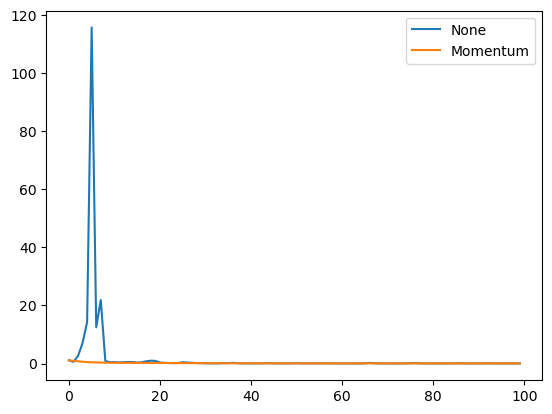

In [212]:
from torch import optim

def train_n_test(lr=0.05, print_loss=True, momentum=0, weight_decay=0):
    # Define the model to optimze
    model = MLP(feature_count, hidden_layer_size, class_count)

    # The optimizer we'll use to update the model parameters
    optimizer = optim.SGD(model.parameters(), lr=0.05, momentum=momentum, weight_decay=weight_decay)

    # Now we define the loss function.
    criterion = nn.CrossEntropyLoss() 

    # Now we iterate over the dataset a number of times. Each iteration of the entire dataset 
    # is called an epoch.
    loss_values = []
    for epoch in range(0, 100):
        # We compute the forward pass of the network
        logits = model.forward(features['train'])
        # Then the value of loss function 
        loss = criterion(logits,  labels['train'])
    
        # How well the network does on the batch is an indication of how well training is 
        # progressing
        if print_loss:
            print("epoch: {} train accuracy: {:2.2f}, loss: {:5.5f}".format(
                epoch,
                accuracy(logits, labels['train']) * 100,
                loss.item()
            ))
        loss_values.append(loss.item())
    
        # Now we compute the backward pass, which populates the `.grad` attributes of the parameters
        loss.backward()
        # Now we update the model parameters using those gradients
        optimizer.step()
        # Now we need to zero out the `.grad` buffers as otherwise on the next backward pass we'll add the 
        # new gradients to the old ones.
        optimizer.zero_grad()
    
    # Finally we can test our model on the test set and get an unbiased estimate of its performance.    
    logits = model.forward(features['test'])    
    test_accuracy = accuracy(logits, labels['test']) * 100
    print("test accuracy: {:2.2f}".format(test_accuracy))
    
    return loss_values

loss_values = train_n_test(lr=0.05, momentum=0.9)

plt.plot([i for i in range(len(loss_vals_before))], loss_vals_before, label="None")
plt.plot([i for i in range(len(loss_values))], loss_values, label="Momentum")
plt.legend()
plt.show()

In [ ]:
up to weight decay